## Performance dominance vs. price volatility

Tournament-wide scatter of |xG margin| against the price range of the Kalshi market that priced the actual outcome across all 104 matches.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Notebook lives in code/, so data/ and output/ live one level up.
ROOT = Path.cwd().parent
FIG_DIR = ROOT / "output" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TEAM_NAME_ALIASES = {
    "Cape Verde": "Cabo Verde",
    "Bosnia and Herzegovina": "Bosnia & Herzegovina",
    "Congo DR": "DR Congo",
    "Ivory Coast": "C\u00f4te d'Ivoire",
    "IR Iran": "Iran",
    "Turkiye": "T\u00fcrkiye",
    "Curacao": "Cura\u00e7ao",
    "Korea Republic": "South Korea",
}

In [2]:
def load_kalshi_outcome_volatility() -> pd.DataFrame:
    markets = pd.read_parquet(ROOT / "data/kalshi/kxwcgame_markets.parquet")
    candles = pd.read_parquet(ROOT / "data/kalshi/candlesticks/kxwcgame_minute.parquet")

    outcome_markets = markets[markets["result"] == "yes"].copy()

    price_range = candles.groupby("market_ticker")["price_close"].agg(lambda s: s.max() - s.min())
    outcome_markets["price_range"] = outcome_markets["market_ticker"].map(price_range)
    outcome_markets = outcome_markets.dropna(subset=["price_range"])

    parts = outcome_markets["event_title"].str.split(" vs ", n=1, expand=True)
    team1 = parts[0].str.strip().replace(TEAM_NAME_ALIASES)
    team2 = parts[1].str.split(":").str[0].str.strip().replace(TEAM_NAME_ALIASES)
    outcome_markets["team_set"] = [frozenset(t) for t in zip(team1, team2)]
    return outcome_markets[["event_ticker", "team_set", "yes_team_subtitle", "price_range"]]


def load_sofascore_xg_margin() -> pd.DataFrame:
    stats = pd.read_parquet(ROOT / "data/sofascore/statistics.parquet")
    schedule = pd.read_parquet(ROOT / "data/sofascore/schedule.parquet")

    xg = stats[(stats["period"] == "ALL") & (stats["stat_name"] == "Expected goals")]
    before = len(xg)
    xg = xg.merge(schedule[["event_id", "home_team", "away_team"]], on="event_id")
    print(f"  xg merge schedule: {before} rows -> {len(xg)} rows")
    xg["team_set"] = [frozenset(t) for t in zip(xg["home_team"], xg["away_team"])]
    xg["xg_margin"] = (xg["home_value"] - xg["away_value"]).abs()
    return xg[["team_set", "xg_margin"]]

In [3]:
kalshi = load_kalshi_outcome_volatility()
xg = load_sofascore_xg_margin()

before = len(kalshi)
merged = kalshi.merge(xg, on="team_set", how="inner")
print(f"kalshi ({before} rows) merge xg ({len(xg)} rows) -> {len(merged)} rows")
unmatched = kalshi[~kalshi["team_set"].isin(xg["team_set"])]
if len(unmatched):
    print("Unmatched (likely a team-name spelling mismatch between sources):")
    for teams in unmatched["team_set"]:
        print(" ", " vs ".join(teams))

corr = merged["xg_margin"].corr(merged["price_range"])
print(f"Pearson r = {corr:.2f}, n = {len(merged)}")

  xg merge schedule: 104 rows -> 104 rows
kalshi (104 rows) merge xg (104 rows) -> 104 rows
Pearson r = -0.38, n = 104


Saved /Users/katemarine/Documents/wc26-prediction-markets/output/figures/dominance_plot.png


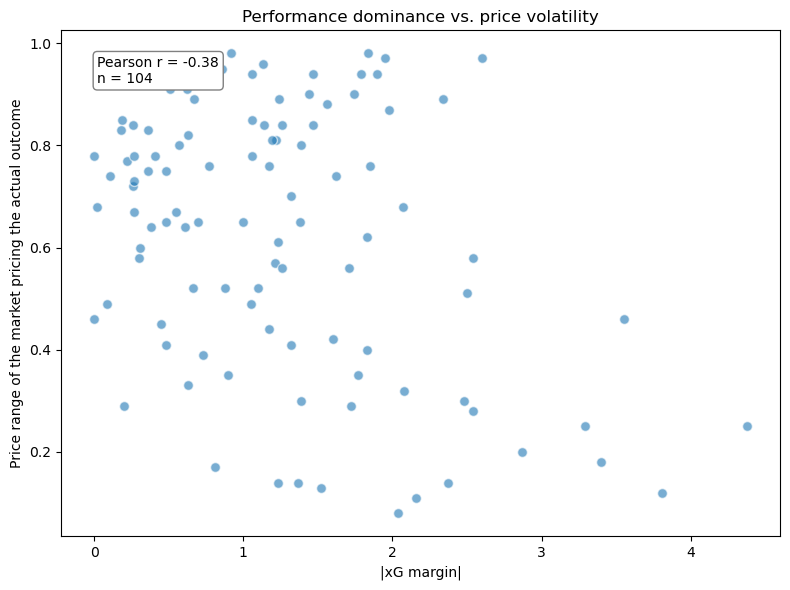

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(merged["xg_margin"], merged["price_range"], alpha=0.6, edgecolor="white", s=50)
ax.set_xlabel("|xG margin|")
ax.set_ylabel("Price range of the market pricing the actual outcome")
ax.set_title("Performance dominance vs. price volatility")
ax.annotate(
    f"Pearson r = {corr:.2f}\nn = {len(merged)}",
    xy=(0.05, 0.95),
    xycoords="axes fraction",
    va="top",
    fontsize=10,
    bbox={"boxstyle": "round", "facecolor": "white", "edgecolor": "gray"},
)

fig.tight_layout()
out_path = FIG_DIR / "dominance_plot.png"
fig.savefig(out_path, dpi=150)
print(f"Saved {out_path}")